### WGAN-G
 #### Issues with GAN
 - mode colapse (like only generate similar bedrooms here, like from only 3 variants or 10,000 variants)
 - memorization is it just memorizing the given data 

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from fastai.conv_learner import *
from fastai.dataset import *
#from Path import PATH
import gzip

In [3]:
#dataset ->lsun-bedrooms ... 4.3GB
#url = 'https://s3.amazonaws.com/fast-ai-imageclas/bedroom.tgz'
#tar -xvzf

In [4]:
PATH = Path()

In [5]:
#PATH = Path('data/lsun/')
IMG_PATH = PATH/'bedroom'
CSV_PATH = PATH/'files.csv'
TMP_PATH = PATH/'tmp'
TMP_PATH.mkdir(exist_ok=True)

In [6]:
files = PATH.glob('bedroom/**/*.jpg')

with CSV_PATH.open('w') as fo:
    for  f in files: fo.write(f'{f.relative_to(IMG_PATH)},0\n')

In [7]:
# Optional - sampling a subset of files
# CSV_PATH = PATH/'files_sample.csv'

In [8]:
# files = PATH.glob('bedroom/**/*.jpg')

# with CSV_PATH.open('w') as fo:
#     for f in files:
#         if random.random()<0.1: fo.write(f'{f.relative_to(IMG_PATH)},0\n')

In [9]:
class ConvBlock(nn.Module):
    def __init__(self, ni, no, ks, stride, bn=True, pad=None):
        super().__init__()
        if pad is None: pad = ks//2//stride
        self.conv = nn.Conv2d(ni, no, ks, stride, padding=pad, bias=False)
        self.bn = nn.BatchNorm2d(no) if bn else None
        self.relu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        x = self.relu(self.conv(x))
        return self.bn(x) if self.bn else x

In [10]:
# WGAN-GP 
class DCGAN_D(nn.Module):
    """ Input is an image and output a scaler number, BN breaks Lipschitz constraint no BN """
    def __init__(self, isize, nc, ndf, n_extra_layers=0):
        super().__init__()
        assert isize % 16 == 0, "isize has to be a multiple of 16"

        self.initial = ConvBlock(nc, ndf, 4, 2, bn=False)
        csize,cndf = isize//2, ndf
        self.extra = nn.Sequential(*[ConvBlock(cndf, cndf, 3, 1, bn=False)
                                    for t in range(n_extra_layers)])
        pyr_layers = []
        #to handle any arbirtrary size of images, and turn them to fixed size i.e. here 4x4
        #append enough stride 2 conv layers until the grid size is decreased to not bigger than 4x4
        while csize > 4: 
            pyr_layers.append(ConvBlock(cndf, cndf*2, 4, 2, bn=False))
            cndf *= 2; csize //= 2
        self.pyramid = nn.Sequential(*pyr_layers)
    
        self.final = nn.Conv2d(cndf, 1, 4, padding=0, bias=False) #one channel output

    def forward(self, input):
        x = self.initial(input)
        x = self.extra(x)
        x = self.pyramid(x)
        return self.final(x).view(x.size(0))

In [11]:
def gradient_penalty(netD, real, fake, lambda_gp=10):
    """ Critic parameters (θ)
    Second derivative (∂²D / ∂θ ∂x) → needed to update weights using the penalty.
    - Critic updates: involve both first (input) and second (parameters) derivatives

    - Generator updates: only first derivatives (through the critic)"""
    bs = real.size(0)
    epsilon = torch.rand(bs,1,1,1)
    if real.is_cuda:epsilon = epsilon.cuda()
    epsilon = V(epsilon)

    x_hat = epsilon * real + (1 - epsilon) * fake
    x_hat = V(x_hat.data, requires_grad=True)

    d_hat = netD(x_hat)

    grad = torch.autograd.grad(
        outputs=d_hat,
        inputs=x_hat,
        grad_outputs=torch.ones_like(d_hat),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    grad = grad.view(bs, -1)
    gp = ((grad.norm(2, dim=1)-1) ** 2).mean()
    return lambda_gp * gp

In [12]:
class DeconvBlock(nn.Module):
    def __init__(self, ni, no, ks, stride, pad, bn=True):
        super().__init__()
        #convTranspose is same as calculation of the gradient of conv
        self.conv = nn.ConvTranspose2d(ni, no, ks, stride, padding=pad, bias=False)
        self.bn = nn.BatchNorm2d(no)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.conv(x))
        return self.bn(x) if self.bn else x

In [13]:
class DCGAN_G(nn.Module):
    """ Input is a vector of random number, aka from paper 'the prior' """
    def __init__(self, isize, nz, nc, ngf, n_extra_layers=0):
        super().__init__()
        assert isize % 16 == 0, "isize has to be a multiple of 16"

        cngf, tisize = ngf//2, 4   #cngf=current number of generator filters, tisize=temp image size
        while tisize !=isize: cngf *=2; tisize*=2
        layers = [DeconvBlock(nz, cngf, 4, 1, 0)] #creates intial 4x4 feature map

        csize,cndf = 4, cngf
        while csize < isize//2: 
            #doubles spatial/grid dimention until final_size/2 while halving num of filters
            layers.append(DeconvBlock(cngf, cngf//2, 4, 2, 1))
            cngf //=2; csize *= 2

        #refinning features without changing dimentions
        layers += [DeconvBlock(cngf, cngf, 3, 1, 1) for t in range(n_extra_layers)] 
        #final upsampling
        layers.append(nn.ConvTranspose2d(cngf, nc, 4, 2, 1, bias=False)) 
        self.features = nn.Sequential(*layers)

    def forward(self, input): return F.tanh(self.features(input))

In [14]:
bs, sz, nz = 64, 64, 100

In [15]:
tfms = tfms_from_stats(inception_stats, sz)
md = ImageClassifierData.from_csv(PATH, 'bedroom', CSV_PATH, tfms=tfms, bs=128,
                                skip_header=False, continuous=True)

In [16]:
md = md.resize(128)

  0%|          | 0/6 [00:00<?, ?it/s]

In [17]:
x, _ = next(iter(md.val_dl))

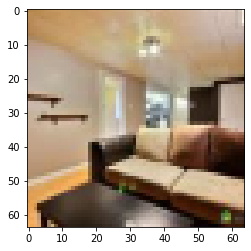

In [18]:
plt.imshow(md.trn_ds.denorm(x)[0]);

In [19]:
netG = DCGAN_G(sz, nz, 3, 64, 1).cuda()
netD = DCGAN_D(sz, 3, 64, 1).cuda()

In [20]:
def create_noise(b): 
    """ A Function that returns a prior vector, noise"""
    return V(torch.zeros(b, nz, 1, 1).normal_(0, 1))

In [21]:
torch.backends.cudnn.benchmark=True

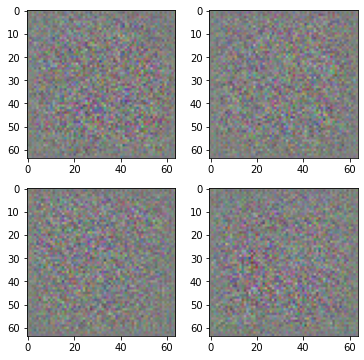

In [22]:
preds = netG(create_noise(4))
preds_ims = md.trn_ds.denorm(preds)

#example of creating noise or prior vector
fig, axes = plt.subplots(2, 2, figsize=(6,6))
for i,ax in enumerate(axes.flat): ax.imshow(preds_ims[i])

In [23]:
def gallery(x, nc=3):
    n, h, w, c = x.shape
    nr = n//nc
    assert n == nr*nc
    return (x.reshape(nr, nc, h, w, c) #(row, column, height, width,color)
               .swapaxes(1, 2) #(row, height, column, width, color)
                .reshape(h*nr, w*nc, c)) #(totalheight, totaleidth, 3(color))

In [24]:
# WGAN paper they use RMSprop
# optimizerD = optim.RMSprop(netD.parameters(), lr=1e-4)
# optimizerG = optim.RMSprop(netG.parameters(), lr = 1e-4)

In [25]:
optimizerD = optim.Adam(netD.parameters(), lr=1e-4, betas=(0.0, 0.9))
optimizerG = optim.Adam(netG.parameters(), lr=1e-4, betas=(0.0, 0.9))

In [26]:
def train(niter, critic_iters=5, lambda_gp=10, first=True): 
    for epoch in trange(niter,desc="Epochs"):
        
        netD.train(); netG.train() #in training mode bn updates and dropout happen but not in eval mode

        data_iter = iter(md.trn_dl)
        n = len(md.trn_dl)
        
        with tqdm(total=n, desc="Batches") as pbar:
            for _ in range(n):
                real = next(data_iter)[0]
                real = V(real)
                bs = real.size(0)
                
                set_trainable(netD, True)
                set_trainable(netG, False)

                #generate one fake batch for all critic steps
                fake = V(netG(create_noise(real.size(0))).detach())
                
                #the descriminator is trained 5 times for everytime generator train once
                for _ in range(critic_iters):
                    #fake = V(netG(create_noise(real.size(0))).detach())
                    netD.zero_grad()
                    
                    real_loss = netD(real) #how much does it look fake, discrimator/critic
                    fake_loss = netD(fake)
                    
                    gp = gradient_penalty(netD, real, fake, lambda_gp=lambda_gp)
                    
                    lossD = fake_loss.mean() - real_loss.mean() + gp #total descriminator loss
                    lossD.backward()
                    optimizerD.step() #gradients with respect to the descriminator
                
                #pbar.update() #update after critic step
                
                set_trainable(netD, False)
                set_trainable(netG, True)
                
                netG.zero_grad()
                fake = netG(create_noise(bs))
                lossG = -netD(fake).mean()
                #the generator parameters are the one getting updated rather than the descriminator
                lossG.backward()
                optimizerG.step() #gradients with respect to the generator
                
                pbar.update()
                         
        print(
            f"Epoch {epoch+1}/{niter} | "
            f"Loss_D: {to_np(lossD):.5f} | "
            f"LossG: {to_np(lossG):.5f} | "
            f"D_real: {to_np(real_loss.mean()):.5f} | " 
            f"Loss_D_fake {to_np(fake_loss.mean()):.5f} "
        )

In [27]:
torch.backends.cudnn.benchmark=True

In [ ]:
train(1, first=False)

Batches:  27%|██▋       | 512/1895 [09:08<25:00,  1.09s/it]

In [ ]:
# set_trainable(netD, True)
# set_trainable(netG, True)
# optimizerD = optim.RMSprop(netD.parameters(), lr=1e-5)
# optimizerG = optim.RMSprop(netG.parameters(), lr=1e-5)

In [ ]:
set_trainable(netD, True)
set_trainable(netG, True)

#wth Adam optim
optimizerD = optim.Adamax(netD.parameters(), lr=1e-5, betas=(0.0, 0.9))
optimizerG = optim.Adamax(netG.parameters(), lr=1e-5, betas=(0.0, 0.9))

In [ ]:
train(1, False)

In [ ]:
fixed_noise = create_noise(bs)

netD.eval(); netG.eval();
fake = netG(fixed_noise).data.cpu()
faked = np.clip(md.trn_ds.denorm(fake),0,1)

plt.figure(figsize=(9,9))
plt.imshow(gallery(faked, 8));